In [ ]:
# Menampilkan file yang diunggah
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import pickle
import io

In [ ]:
df = pd.read_csv("Data Historis INDF.csv", delimiter=";")
# Drop unwanted unnamed columns if present
df = df[['Tanggal', 'Terakhir']]
# Show dataframe (verifikasi bahwa kolom Unnamed dihapus)
df

,Tanggal,Terakhir
0,23/10/15,6.225
1,26/10/15,6.225
2,27/10/15,6.200
3,28/10/15,6.075
4,29/10/15,5.650
...,...,...
2410,16/10/25,7.075
2411,17/10/25,7.125
2412,20/10/25,7.250
2413,21/10/25,7.275


In [ ]:
# Menampilkan data
print("Historis Saham INDF:")
print(f"\nShape data: {df.shape}")
df

Historis Saham INDF:

Shape data: (2415, 2)


,Tanggal,Terakhir
0,23/10/15,6.225
1,26/10/15,6.225
2,27/10/15,6.200
3,28/10/15,6.075
4,29/10/15,5.650
...,...,...
2410,16/10/25,7.075
2411,17/10/25,7.125
2412,20/10/25,7.250
2413,21/10/25,7.275


In [ ]:
# Normalize and parse date column (handle different possible column names)
date_col = None
for c in ['Tanggal', 'tanggal', 'Date', 'date']:
    if c in df.columns:
        date_col = c
        break
if date_col is None:
    raise KeyError('No date column found. Expected one of: Tanggal, tanggal, Date, date')
# Robust parsing: try common formats first, then fallback to generic parser
date_series = df[date_col].astype(str).str.strip()
formats = ['%d/%m/%Y', '%Y-%m-%d', '%d-%m-%Y', '%d %b %Y', '%d %B %Y']
final_parsed = pd.Series([pd.NaT] * len(date_series))
for fmt in formats:
    parsed = pd.to_datetime(date_series, format=fmt, dayfirst=True, errors='coerce')
    final_parsed = final_parsed.combine_first(parsed)
if final_parsed.isna().any():
    remaining_idx = final_parsed.isna()
    final_parsed.loc[remaining_idx] = pd.to_datetime(date_series[remaining_idx], dayfirst=True, errors='coerce')
df[date_col] = final_parsed
# Rename to consistent column name 'Tanggal'
if date_col != 'Tanggal':
    df = df.rename(columns={date_col: 'Tanggal'})
# Ensure price column is named 'Terakhir' (handle possible variants)
price_col = None
for c in ['Terakhir', 'terakhir', 'Close', 'close']:
    if c in df.columns:
        price_col = c
        break
if price_col is None:
    raise KeyError('No price column found. Expected one of: Terakhir, terakhir, Close, close')
if price_col != 'Terakhir':
    df = df.rename(columns={price_col: 'Terakhir'})
# Sort by the normalized date column
df = df.sort_values('Tanggal')

/var/folders/wy/pyy9phgx4kngk0b6dmzdhvdh0000gn/T/ipykernel_15152/3236093865.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  final_parsed.loc[remaining_idx] = pd.to_datetime(date_series[remaining_idx], dayfirst=True, errors='coerce')


In [ ]:
df = df.sort_values('Tanggal')
data = df.set_index('Tanggal')
data

,Terakhir
Tanggal,
2015-10-23,6.225
2015-10-26,6.225
2015-10-27,6.200
2015-10-28,6.075
2015-10-29,5.650
...,...
2025-10-16,7.075
2025-10-17,7.125
2025-10-20,7.250


In [ ]:
# Deskripsi data yang digunakan
print("Deskripsi Data:")
print(data.describe())

Deskripsi Data:
          Terakhir
count  2415.000000
mean      7.023333
std       0.792933
min       4.875000
25%       6.400000
50%       6.950000
75%       7.650000
max       9.150000


In [ ]:
# Cek missing values
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
Terakhir    0
dtype: int64


In [ ]:
# Cek tanggal duplikat
data = data.groupby('Tanggal').mean().reset_index()

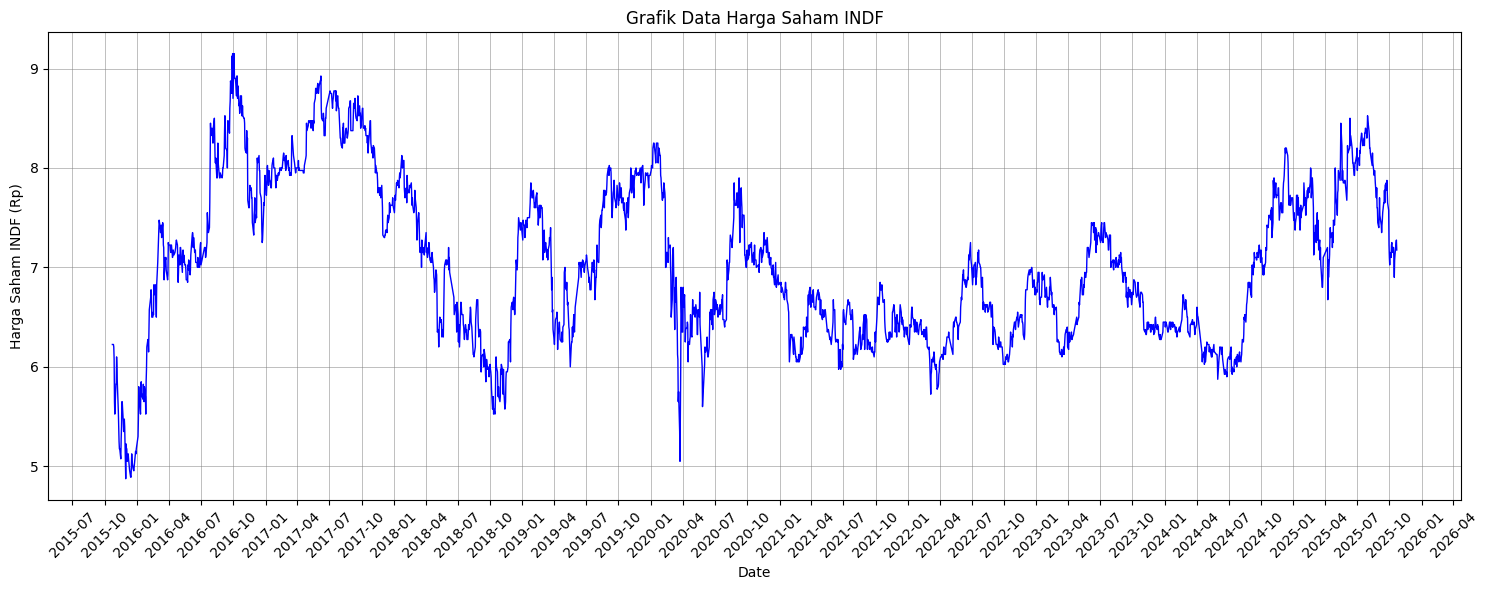

In [ ]:
"""#Grafik Data"""

# Membuat plot data
plt.figure(figsize=(15,6))
plt.plot(data['Tanggal'], data['Terakhir'], color='blue', linewidth=1)

# Menambahkan judul dan label sumbu
plt.title('Grafik Data Harga Saham INDF')
plt.xlabel('Date')
plt.ylabel('Harga Saham INDF (Rp)')

# Atur sumbu x agar mudah dibaca
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Menampilkan tanggal setiap 3 bulan
plt.xticks(rotation=45)
plt.tight_layout()

# Menambahkan grid
plt.grid(True, linestyle='-', linewidth=0.5, color='gray', alpha=0.7)

# Menampilkan plot
plt.show()

Outliers:
 Empty DataFrame
Columns: [Tanggal, Terakhir]
Index: []
Tidak ada outlier pada data.


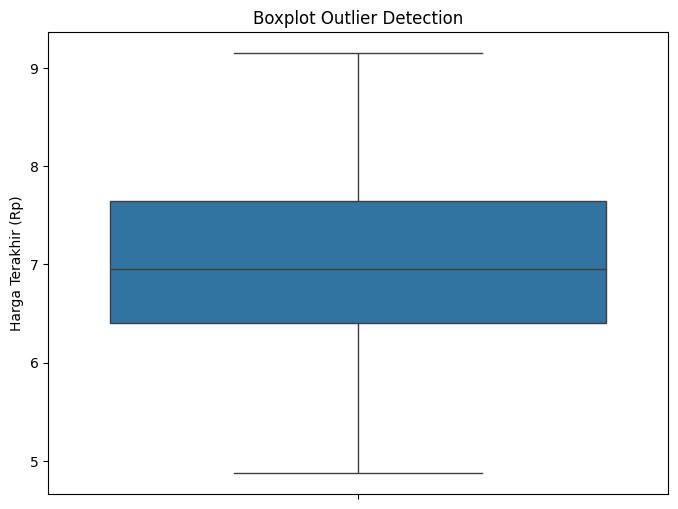

In [ ]:
"""#Pengecekan Data

##Pengecekan Outlier
"""
# Import seaborn, install if missing
import importlib, subprocess, sys
try:
    import seaborn as sns
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'seaborn'])
    import seaborn as sns
import matplotlib.pyplot as plt

# Cek Outlier
Q1 = data['Terakhir'].quantile(0.25)
Q3 = data['Terakhir'].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Deteksi outlier
outliers = data[(data['Terakhir'] < lower_bound) | (data['Terakhir'] > upper_bound)]
print("Outliers:\n", outliers)

# Menilai apakah ada outlier atau tidak
if outliers.empty:
    print("Tidak ada outlier pada data.")
else:
    print(f"Terdapat {len(outliers)} outlier(s) pada data.")

# Visualisasi boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data['Terakhir'])
plt.title("Boxplot Outlier Detection")
plt.ylabel("Harga Terakhir (Rp)")
plt.show()

In [ ]:
!pip install keras-tcn

Training data shape: (1682, 12, 1), (1682, 1)
Validation data shape: (360, 12, 1), (360, 1)
Testing data shape: (361, 12, 1), (361, 1)


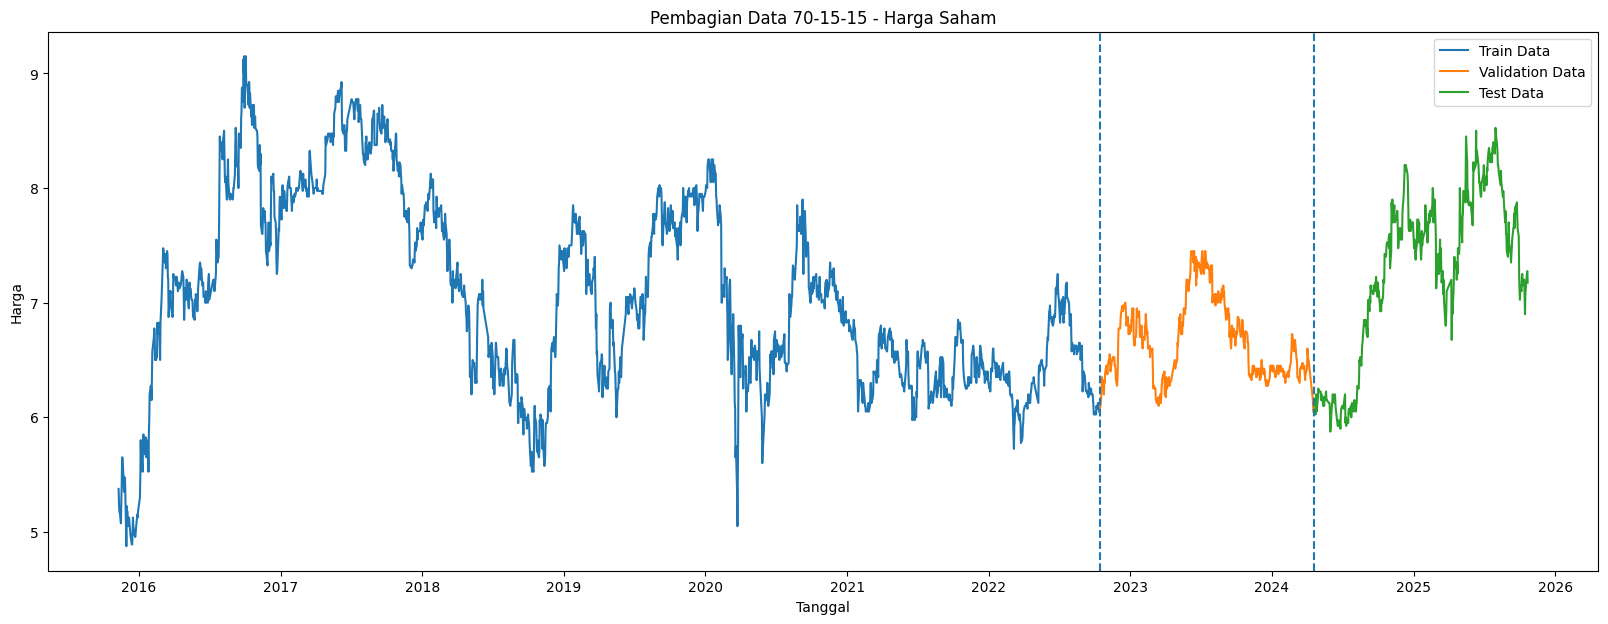

In [ ]:
"""##Pembagian data 70-15-15"""

import numpy as np

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
scaledDataMat = scaler.fit_transform(data[['Terakhir']])

# Menyiapkan data untuk model TCN-BiGRU
sequence_length = 12  # Panjang sequence yang diinginkan
X = []
y = []
for i in range(len(scaledDataMat) - sequence_length):
    X.append(scaledDataMat[i:i+sequence_length])
    y.append(scaledDataMat[i+sequence_length])
X = np.array(X)
y = np.array(y)

# Pembagian data(70% train, 15% validation, 15% test)
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

# Bagi data menjadi training, validation, dan testing
X_train, X_val, X_test = X[:train_size], X[train_size:train_size + val_size], X[train_size + val_size:]
y_train, y_val, y_test = y[:train_size], y[train_size:train_size + val_size], y[train_size + val_size:]

# Cetak bentuk data yang dihasilkan
print(f'Training data shape: {X_train.shape}, {y_train.shape}')
print(f'Validation data shape: {X_val.shape}, {y_val.shape}')
print(f'Testing data shape: {X_test.shape}, {y_test.shape}')

# Pembagian data 70 - 15 - 15
start_idx = sequence_length

train_end = start_idx + train_size
val_end = train_end + val_size

data_train = df.iloc[start_idx:train_end]
data_val = df.iloc[train_end:val_end]
data_test = df.iloc[val_end:]

# Visualisasi data
plt.figure(figsize=(20, 7))

plt.plot(data_train['Tanggal'], data_train['Terakhir'], label='Train Data')
plt.plot(data_val['Tanggal'], data_val['Terakhir'], label='Validation Data')
plt.plot(data_test['Tanggal'], data_test['Terakhir'], label='Test Data')

plt.axvline(x=data_val['Tanggal'].iloc[0], linestyle='--')
plt.axvline(x=data_test['Tanggal'].iloc[0], linestyle='--')

plt.title('Pembagian Data 70-15-15 - Harga Saham')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()
plt.show()

In [ ]:
import sys
!{sys.executable} -m pip install tensorflow

In [ ]:
"""##Cari Best Model TCN-BiGRU"""
import sys
!{sys.executable} -m pip install keras-tcn
import tensorflow as tf
tf.random.set_seed(1234)

# Set memory growth untuk GPU (jika ada)
try:
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
except:
    pass

import itertools
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Bidirectional, GRU, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tcn import TCN
from sklearn.metrics import mean_absolute_percentage_error
import pandas as pd

# Menentukan parameter untuk TCN-BiGRU (dikurangi untuk menghindari error)
tcn_filters = [16, 32, 64 ,128]  
tcn_kernel_sizes = [2, 3, 5]  
tcn_dilations = [(1, 2, 4)] 
gru_units = [16, 32, 64, 128]  
dropout_rates = [0.1]
batch_sizes = [8, 16]  
learning_rates = [0.0001, 0.00001]  # Adjust learning rate
losses = ['mse']
epochs = 5  # Dikurangi untuk testing CARI LOSES VALUE BUAT DAPETIN EPOCH BAGUS

# Buat kombinasi yang lebih sederhana
hyperparameter_combinations = list(itertools.product(
    tcn_filters, tcn_kernel_sizes, tcn_dilations, gru_units, dropout_rates, batch_sizes, learning_rates
))

results = []
best_mape = float('inf')
best_model = None
best_params = None

print(f"Total kombinasi yang akan ditest: {len(hyperparameter_combinations)}")

for i, (tcn_filter, kernel_size, dilations, gru_unit, dropout_rate, batch_size_param, lr) in enumerate(hyperparameter_combinations):
    print(f"\nTesting kombinasi {i+1}/{len(hyperparameter_combinations)}")
    
    try:
        # Clear session untuk menghindari memory issues
        tf.keras.backend.clear_session()
        
        model = Sequential()
        
        # TCN Layer
        model.add(TCN(
            nb_filters=tcn_filter,
            kernel_size=kernel_size,
            dilations=list(dilations),  # Convert tuple to list
            return_sequences=True,
            activation='relu',
            input_shape=(sequence_length, 1),
            padding='causal'
        ))
        
        # Dropout layer
        model.add(Dropout(dropout_rate))
        
        # Bidirectional GRU
        model.add(Bidirectional(GRU(units=gru_unit)))
        
        # Dense output layer
        model.add(Dense(units=1))

        optimizer = Adam(learning_rate=lr)
        model.compile(optimizer=optimizer, loss=losses[0])

        early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

        history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size_param, 
                  validation_data=(X_val, y_val), verbose=0, callbacks=[early_stopping])

        y_pred_train = model.predict(X_train, verbose=0)
        y_pred_val = model.predict(X_val, verbose=0)
        y_pred_test = model.predict(X_test, verbose=0)

        # Transformasi nilai aktual dan prediksi
        y_train_original = scaler.inverse_transform(y_train)
        y_val_original = scaler.inverse_transform(y_val)
        y_test_original = scaler.inverse_transform(y_test)
        y_pred_train_original = scaler.inverse_transform(y_pred_train)
        y_pred_val_original = scaler.inverse_transform(y_pred_val)
        y_pred_test_original = scaler.inverse_transform(y_pred_test)

        mape_train = mean_absolute_percentage_error(y_train_original, y_pred_train_original) * 100
        mape_val = mean_absolute_percentage_error(y_val_original, y_pred_val_original) * 100
        mape_test = mean_absolute_percentage_error(y_test_original, y_pred_test_original) * 100

        print(f"TCN Filters: {tcn_filter}, Kernel: {kernel_size}, Dilations: {dilations}")
        print(f"GRU Units: {gru_unit}, Dropout: {dropout_rate}, Batch Size: {batch_size_param}, LR: {lr}")
        print(f"MAPE Train: {mape_train:.2f}%")
        print(f"MAPE Val: {mape_val:.2f}%")
        print(f"MAPE Test: {mape_test:.2f}%")

        results.append([tcn_filter, kernel_size, str(dilations), gru_unit, dropout_rate, batch_size_param, lr, 
                       mape_train, mape_val, mape_test])

        if mape_val < best_mape:
            best_mape = mape_val
            best_model = tf.keras.models.clone_model(model)
            best_model.set_weights(model.get_weights())
            best_params = [tcn_filter, kernel_size, dilations, gru_unit, dropout_rate, batch_size_param, lr]
            
    except Exception as e:
        print(f"Error pada kombinasi {i+1}: {str(e)}")
        continue

print("\nBest Model Hyperparameters:", best_params)
if best_model:
    print("Best Model Summary:")
    print(best_model.summary())

results_df = pd.DataFrame(results, columns=['TCN_Filters', 'Kernel_Size', 'Dilations', 'GRU_Units', 
                                          'Dropout', 'Batch_Size', 'Learning_Rate', 'MAPE_Train', 'MAPE_Val', 'MAPE_Test'])
print("\nAll Results:")
display(results_df)

Total kombinasi yang akan ditest: 16

Testing kombinasi 1/16


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


TCN Filters: 32, Kernel: 2, Dilations: (1, 2, 4)
GRU Units: 32, Dropout: 0.1, Batch Size: 8, LR: 0.0001
MAPE Train: 1.49%
MAPE Val: 0.95%
MAPE Test: 1.44%

Testing kombinasi 2/16


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


TCN Filters: 32, Kernel: 2, Dilations: (1, 2, 4)
GRU Units: 32, Dropout: 0.1, Batch Size: 16, LR: 0.0001
MAPE Train: 1.65%
MAPE Val: 1.06%
MAPE Test: 1.56%

Testing kombinasi 3/16


...

 Trainable params: 91,649 (358.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 183,300 (716.02 KB)

None

All Results:


,TCN_Filters,Kernel_Size,Dilations,GRU_Units,Dropout,Batch_Size,Learning_Rate,MAPE_Train,MAPE_Val,MAPE_Test
0,32,2,"(1, 2, 4)",32,0.1,8,0.0001,1.487005,0.952102,1.436175
1,32,2,"(1, 2, 4)",32,0.1,16,0.0001,1.651219,1.063355,1.561310
2,32,2,"(1, 2, 4)",64,0.1,8,0.0001,1.649223,1.112334,1.524266
3,32,2,"(1, 2, 4)",64,0.1,16,0.0001,1.879914,1.317286,1.766557
4,32,3,"(1, 2, 4)",32,0.1,8,0.0001,2.364519,1.599875,2.259883
5,32,3,"(1, 2, 4)",32,0.1,16,0.0001,1.533661,1.035745,1.373945
6,32,3,"(1, 2, 4)",64,0.1,8,0.0001,1.616546,1.046310,1.537784
7,32,3,"(1, 2, 4)",64,0.1,16,0.0001,1.539422,1.009570,1.346507
8,64,2,"(1, 2, 4)",32,0.1,8,0.0001,2.619340,1.354037,2.591685
9,64,2,"(1, 2, 4)",32,0.1,16,0.0001,1.649176,1.025477,1.572663


In [ ]:
last_sequence = scaledDataMat[-sequence_length:]
last_sequence = last_sequence.reshape(1, sequence_length, 1)

pred = best_model.predict(last_sequence)
pred_real = scaler.inverse_transform(pred)

print("Forecast besok:", pred_real[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Forecast besok: 7.191142


In [ ]:
# Predict
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)
val_pred = best_model.predict(X_val)
# Inverse scaling (BALIK KE HARGA ASLI)
train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)
val_pred = scaler.inverse_transform(val_pred)

y_train_real = scaler.inverse_transform(y_train)
y_test_real = scaler.inverse_transform(y_test)
y_val_real = scaler.inverse_transform(y_val)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
import numpy as np

train_plot = np.empty(len(df))
train_plot[:] = np.nan

test_plot = np.empty(len(df))
test_plot[:] = np.nan

In [ ]:
# Train
train_plot[sequence_length:train_size+sequence_length] = train_pred.flatten()

# Test
test_start = train_size + val_size + sequence_length
test_plot[test_start:test_start+len(test_pred)] = test_pred.flatten()

# Validation
val_start = train_size + sequence_length
val_plot = np.empty(len(df))
val_plot[:] = np.nan
val_plot[val_start:val_start+len(val_pred)] = val_pred.flatten()

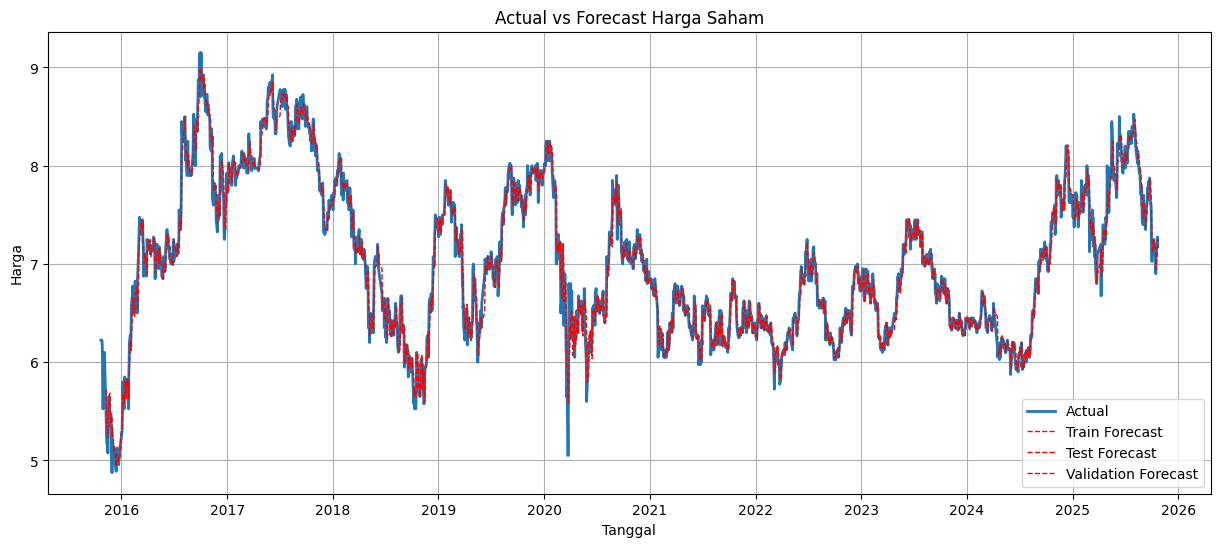

In [ ]:
# ganti : grafik actual dan forecast aja (2 line only)
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

# Actual (DATA ASLI)
plt.plot(df['Tanggal'], df['Terakhir'], label='Actual', linewidth=2)

# Forecast
plt.plot(df['Tanggal'], train_plot, label='Train Forecast', color='red', linestyle='--', linewidth=1)
plt.plot(df['Tanggal'], test_plot, label='Test Forecast', color='red', linestyle='--', linewidth=1)
plt.plot(df['Tanggal'], val_plot, label='Validation Forecast', color='red', linestyle='--', linewidth=1)

plt.title("Actual vs Forecast Harga Saham")
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.legend()
plt.grid()

plt.show()

In [ ]:
# pastikan ini sudah ada di awal (sekali saja cukup)
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

df_plot = df.copy()

# WAJIB: sort berdasarkan tanggal
df_plot['Tanggal'] = pd.to_datetime(df_plot['Tanggal'])
df_plot = df_plot.sort_values(by='Tanggal').reset_index(drop=True)
df_plot['Forecast'] = np.nan

# masukin train
df_plot['Forecast'].iloc[sequence_length:train_size+sequence_length] = train_pred.flatten()

# masukin test
df_plot['Forecast'].iloc[test_start:test_start+len(test_pred)] = test_pred.flatten()

last_14 = df_plot.tail(30)

# next business day (biar gak kena weekend)
next_date = df['Tanggal'].iloc[-1] + pd.offsets.BDay(1)
next_value = pred_real[0][0]

/var/folders/wy/pyy9phgx4kngk0b6dmzdhvdh0000gn/T/ipykernel_15152/4003562217.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_plot['Forecast'].iloc[sequence_length:train_size+sequence_length] = train_pred.flatten()
/var/folders/wy/pyy9

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_test_original))
mae = mean_absolute_error(y_test_original, y_pred_test_original)
r2 = r2_score(y_test_original, y_pred_test_original)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

RMSE: 0.1556
MAE: 0.1169
R² Score: 0.9548


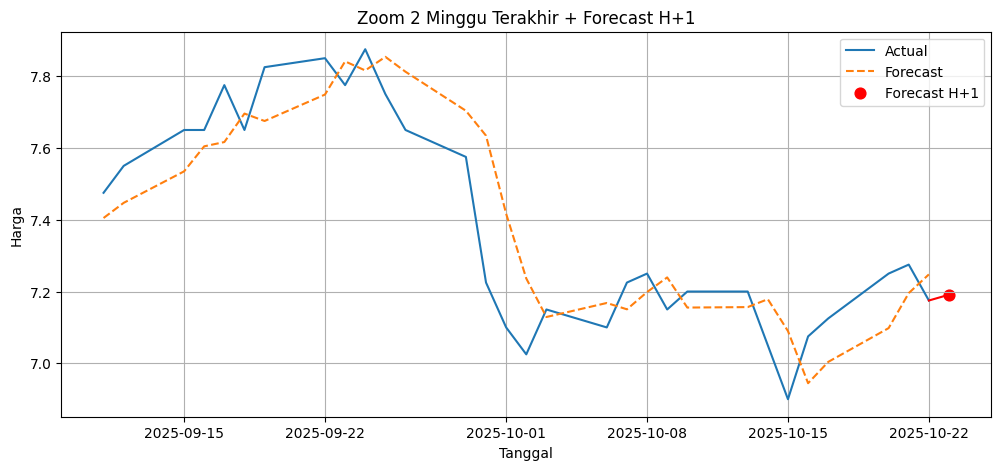

In [ ]:
plt.figure(figsize=(12,5))

# actual
plt.plot(last_14['Tanggal'], last_14['Terakhir'], 
         label='Actual')

# forecast (overlap sama actual)
plt.plot(last_14['Tanggal'], last_14['Forecast'], 
         label='Forecast', linestyle='--')

# titik forecast H+1
plt.scatter(next_date, next_value, 
            color='red', label='Forecast H+1', s=60)

# garis bantu ke H+1
plt.plot([last_14['Tanggal'].iloc[-1], next_date],
         [last_14['Terakhir'].iloc[-1], next_value], color='red')

plt.title("Zoom 2 Minggu Terakhir + Forecast H+1")
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.legend()
plt.grid()

plt.show()

In [ ]:
print("Forecast besok:", pred_real[0][0])

Forecast besok: 7.191142


In [ ]:
import pickle

pickle.dump(best_model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

best_model.save("model.keras")

import pickle
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [ ]:
last_sequence = scaledDataMat[-sequence_length:]
last_sequence = last_sequence.reshape(1, sequence_length, 1)

import numpy as np
np.save("last_sequence.npy", last_sequence)

print("last_sequence berhasil disimpan!")

last_sequence berhasil disimpan!
